In [9]:
import ast
import math
from collections import Counter
from igraph import Graph
from itertools import combinations


#############################################################
# RARITY OF A RULE
#############################################################

def rarity_rule(rule, global_frequency):

    rarity = 0.0

    for pair in rule:

        rarity += global_frequency[pair]

    return rarity / len(rule)

#############################################################
# GLOBAL ATTRIBUTE-VALUE FREQUENCY
#############################################################

from collections import Counter

def compute_global_frequency(rules):

    counter = Counter()

    total_pairs = 0

    for rule in rules:

        for pair in rule:

            counter[pair] += 1
            total_pairs += 1

    freq = {}

    for pair, count in counter.items():

        freq[pair] = count / total_pairs

    return freq

#############################################################
# REUSE OF A RULE
#############################################################

def reuse_rule(rule, community_id, community_frequency):

    reuse = 0.0

    freq = community_frequency[community_id]

    for pair in rule:

        reuse += freq[pair]

    return reuse / len(rule)

#############################################################
# COMMUNITY ATTRIBUTE-VALUE FREQUENCY
#############################################################

from collections import defaultdict

def compute_community_frequency(rules, membership):

    community_rules = defaultdict(list)

    # Agrupar reglas por comunidad
    for idx, comm in enumerate(membership):

        community_rules[comm].append(idx)

    community_frequency = {}

    for comm, rule_ids in community_rules.items():

        counter = Counter()

        n_rules = len(rule_ids)

        for rid in rule_ids:

            # Para evitar contar dos veces el mismo atributo si aparece repetido
            for pair in set(rules[rid]):

                counter[pair] += 1

        freq = {}

        for pair, count in counter.items():

            freq[pair] = count / n_rules

        community_frequency[comm] = freq

    return community_frequency

def jaccard_similarity(rule1, rule2):

    s1 = set(rule1)
    s2 = set(rule2)

    inter = len(s1.intersection(s2))
    union = len(s1.union(s2))

    if union == 0:
        return 0

    return inter / union

#############################################################
# NKC METRIC
#############################################################

def compute_NKC(

        rules,

        membership,

        alpha=1

):

    global_frequency = compute_global_frequency(

        rules

    )

    community_frequency = compute_community_frequency(

        rules,

        membership

    )

    nkc = 0

    details = []

    for idx, rule in enumerate(rules):

        size = len(rule)

        rarity = rarity_rule(

            rule,

            global_frequency

        )

        reuse = reuse_rule(

            rule,

            membership[idx],

            community_frequency

        )

        score = (

            size ** alpha

        ) * (

            (rarity + reuse) / 2

        )

        nkc += score

        details.append({

            "rule": idx,

            "community": membership[idx],

            "size": size,

            "rarity": rarity,

            "reuse": reuse,

            "complexity": score

        })

    return nkc, details

#############################################################
# COMMUNITY DETECTION
#############################################################

def detect_communities(graph):

    communities = graph.community_multilevel(
        weights=graph.es["weight"]
    )

    graph.vs["community"] = communities.membership

    return communities

#############################################################
# RULE GRAPH
#############################################################

def build_rule_graph(rules, threshold=0.5):

    g = Graph()

    g.add_vertices(len(rules))

    edges = []
    weights = []

    for i, j in combinations(range(len(rules)), 2):

        sim = jaccard_similarity(
            rules[i],
            rules[j]
        )

        if sim >= threshold:

            edges.append((i, j))
            weights.append(sim)

    g.add_edges(edges)

    g.es["weight"] = weights

    return g

def load_rules(file_name):

    rules = []

    with open(file_name, "r") as f:

        for line in f:

            line = line.strip()

            if line == "":
                continue

            rule = ast.literal_eval(line)

            attrs = []

            for att in rule[1]:

                attrs.append(
                    (att[0], str(att[1]))
                )

            rules.append(attrs)

    return rules


#############################################################
# WSC
#############################################################

def compute_wsc(rules):

    return sum(len(rule) for rule in rules)


#############################################################
# GLOBAL FREQUENCIES
#############################################################

def compute_global_frequencies(rules):

    counter = Counter()

    total_pairs = 0

    for rule in rules:

        for pair in rule:

            counter[pair] += 1
            total_pairs += 1

    frequencies = {}

    for pair, count in counter.items():

        frequencies[pair] = count / total_pairs

    return frequencies

#############################################################
# COMMUNITY REUSE FACTOR
#############################################################

def compute_reuse_factor(rules, membership):

    reuse = {}

    n_communities = max(membership) + 1

    for cid in range(n_communities):

        unique_pairs = set()

        total_pairs = 0

        for idx, rule in enumerate(rules):

            if membership[idx] != cid:
                continue

            total_pairs += len(rule)

            for pair in rule:
                unique_pairs.add(pair)

        if total_pairs == 0:

            reuse[cid] = 1.0

        else:

            reuse[cid] = len(unique_pairs) / total_pairs

    return reuse

#############################################################
# SHANNON RARITY
#############################################################

def rarity_rule(rule, frequencies):

    rarity = 0

    for pair in rule:

        rarity += frequencies[pair]

    return rarity / len(rule)


#############################################################
# NEW METRIC
#############################################################

def compute_new_metric(
        rules,
        membership,
        alpha=1.0,
        beta=1.0,
        gamma=1.0
):

    frequencies = compute_global_frequencies(
        rules
    )
    print("Frequency: ", frequencies)

    reuse_factor = compute_reuse_factor(
    rules,
    membership
    )

    complexity = 0

    details = []

    for idx, rule in enumerate(rules):

        size = len(rule)

        rarity = rarity_rule(
            rule,
            frequencies
        )

        community = membership[idx]

        reuse = reuse_factor[community]
        print("Size: ", size ** alpha  , " Rarity: ", rarity,"Reuse: ", reuse)

        score = (
            (size ** alpha)
            *
            (0 + beta * rarity)
            *
            (0 + gamma * (reuse))
        )

        complexity += score

        details.append({

            "rule": idx,

            "size": size,

            "rarity": rarity,

            "complexity": score

        })

    return complexity, details


#############################################################
# PRINT COMPARISON
#############################################################

def compare_metrics(file_name):

    rules = load_rules(file_name)

    ####################################################
    # RULE GRAPH
    ####################################################

    graph = build_rule_graph(
        rules,
        threshold=0.25
    )

    ####################################################
    # COMMUNITY DETECTION
    ####################################################

    communities = detect_communities(graph)
    print("\nRule Graph")
    print("---------------------------")
    print("Nodes:", graph.vcount())
    print("Edges:", graph.ecount())
    print("Density:", round(graph.density(),4))

    print("\nCommunities:", len(communities))

    sizes = [len(c) for c in communities]

    print("Community sizes:", sizes)

    wsc = compute_wsc(rules)



    new_metric, details = compute_new_metric(
        rules,
        communities.membership,
        alpha=1,
        beta=1,
        gamma=1
    )

    print("=" * 60)

    print("Policy")

    print("=" * 60)

    print("Rules:", len(rules))

    print("WSC:", round(wsc, 2))

    print("New Metric:", round(new_metric, 2))

    print()

    print("=" * 60)

    print("Per-rule analysis")

    print("=" * 60)

    nkc, details = compute_NKC(

        rules,

        communities.membership,

        alpha=1

    
    )

    print("="*70)

    print("Rule | Comm | Size | Rareza | Reuso | NKC")

    print("="*70)

    for d in details:

        print(

            f"{d['rule']:3d} | "

            f"{d['community']:3d} | "

            f"{d['size']:2d} | "

            f"{d['rarity']:.3f} | "

            f"{d['reuse']:.3f} | "

            f"{d['complexity']:.3f}"

    )
        
    nkc_total = sum(d["complexity"] for d in details)

    print(f"NKC(G_R): {nkc_total:.4f}")
        


#############################################################

if __name__ == "__main__":

    compare_metrics("/Users/ddiaz/Documents/code/phd-thesis-lab/17_NuevoAnalisisP1/reglas_abac_karimi_iot.txt")
    #compare_metrics("/home/daniel/Documents/phd/phd-thesis-lab/17_NuevoAnalisisP1/reglas_abac.txt")


Rule Graph
---------------------------
Nodes: 26
Edges: 82
Density: 0.2523

Communities: 3
Community sizes: [10, 7, 9]
Frequency:  {('area', 'bedroom'): 0.10112359550561797, ('area', ''): 0.11235955056179775, ('timeday', 'day'): 0.0449438202247191, ('mode', 'disarmed'): 0.0449438202247191, ('mode', ''): 0.056179775280898875, ('lockstatus', ''): 0.15730337078651685, ('op', 'control'): 0.06741573033707865, ('health', 'emergency'): 0.0449438202247191, ('lockstatus', 'locked'): 0.056179775280898875, ('location', 'backyard'): 0.033707865168539325, ('mode', 'night'): 0.033707865168539325, ('location', 'bedroom'): 0.02247191011235955, ('mode', 'armed'): 0.02247191011235955, ('timeday', 'midnight'): 0.033707865168539325, ('role', 'user'): 0.02247191011235955, ('health', 'anormal'): 0.02247191011235955, ('role', 'guest'): 0.033707865168539325, ('timeday', 'midday'): 0.011235955056179775, ('role', 'child'): 0.02247191011235955, ('age', '7'): 0.011235955056179775, ('health', 'normal'): 0.0112359

In [10]:
import numpy as np
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D

#############################################################
# NKC PARAMETER PROFILING
#############################################################

def profile_nkc(alpha=1):

    rarity = np.linspace(0, 1, 60)

    reuse = np.linspace(0, 1, 60)

    RARITY, REUSE = np.meshgrid(rarity, reuse)

    rule_sizes = range(2, 13)

    fig = plt.figure(figsize=(18, 12))

    for idx, size in enumerate(rule_sizes):

        ax = fig.add_subplot(
            3,
            4,
            idx + 1,
            projection='3d'
        )

        NKC = (size ** alpha) * ((RARITY + REUSE) / 2)

        surf = ax.plot_surface(

            RARITY,

            REUSE,

            NKC,

            cmap='viridis',

            edgecolor='none'

        )

        ax.set_title(f"|r| = {size}")

        ax.set_xlabel("Rarity")

        ax.set_ylabel("Reuse")

        ax.set_zlabel("NKC")

        ax.view_init(
            elev=30,
            azim=-130
        )

    plt.tight_layout()

    plt.show()

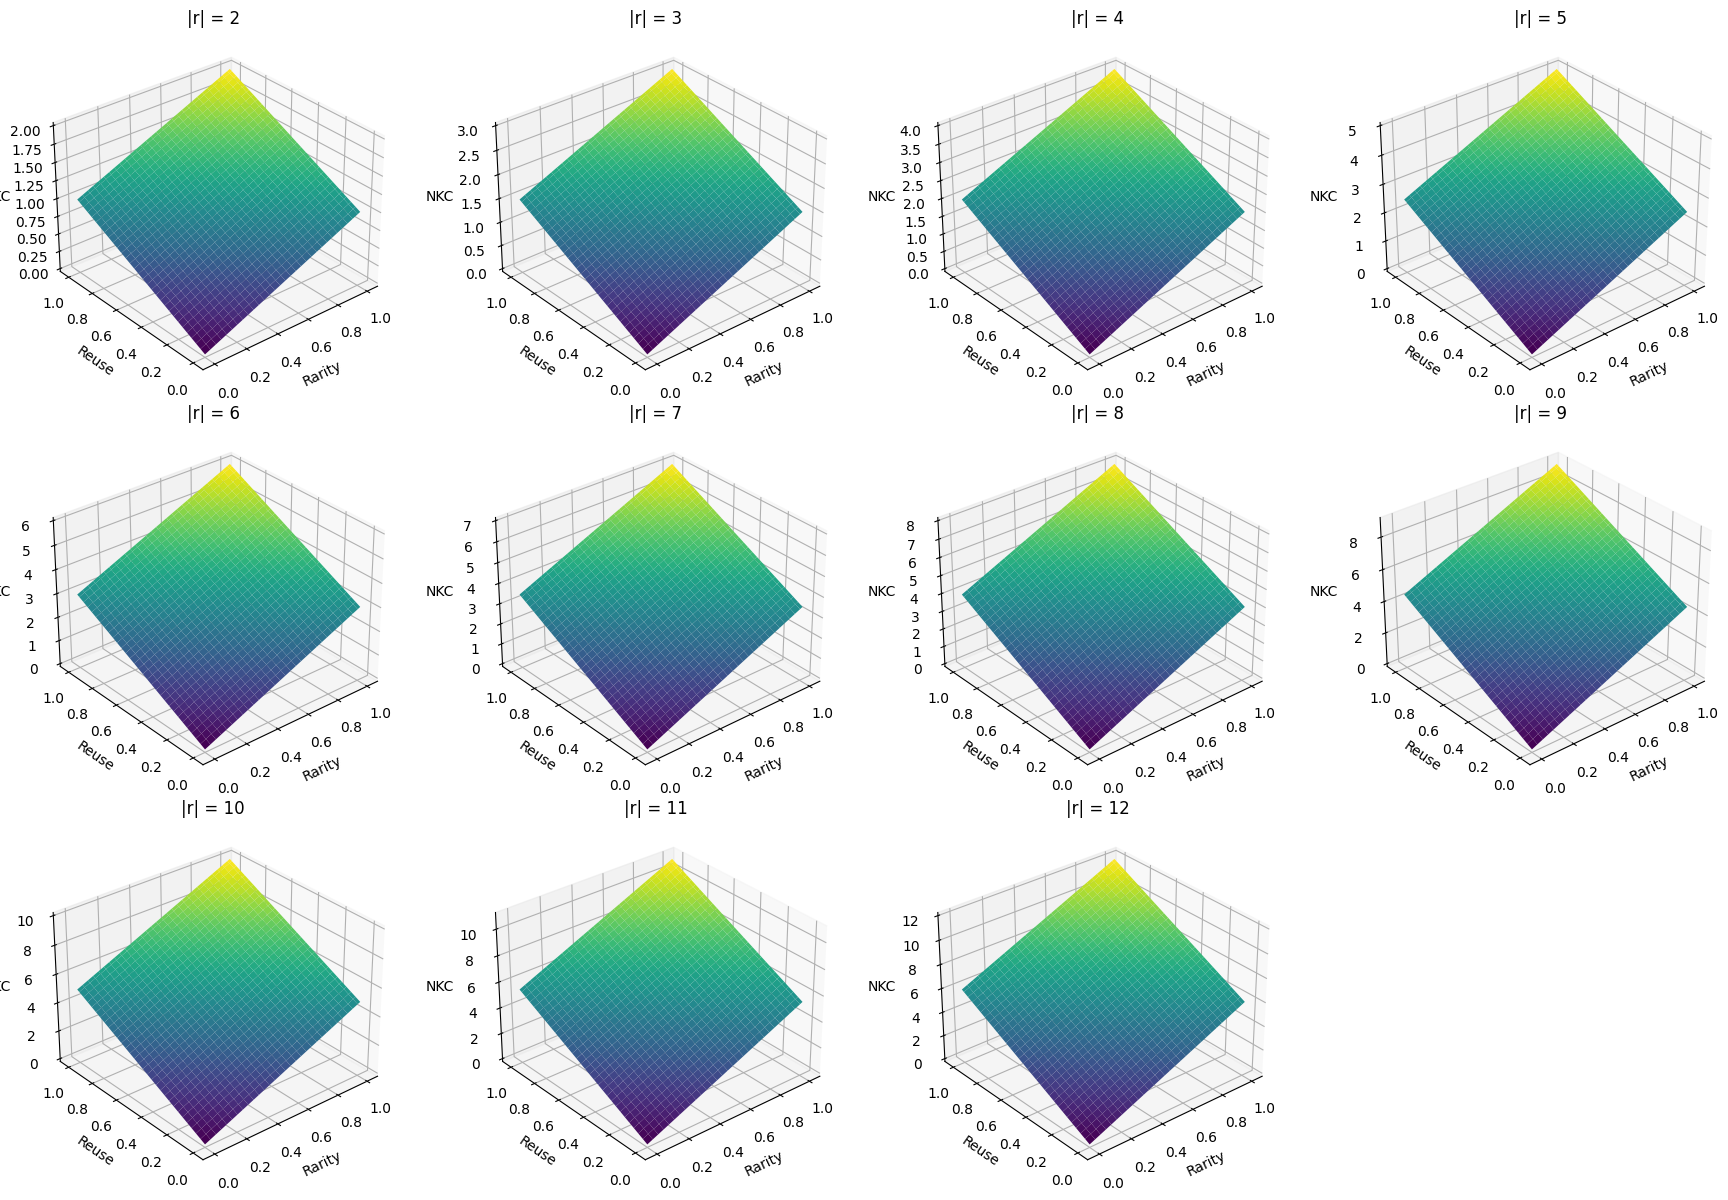

In [11]:
profile_nkc()

In [12]:
#############################################################
# NKC PROFILE
#############################################################

def profile_nkc(alpha=1):

    mean_complexity = np.linspace(0, 1, 100)

    rule_size = np.linspace(2, 12, 100)

    X, Y = np.meshgrid(

        mean_complexity,

        rule_size

    )

    Z = (Y ** alpha) * X

    fig = plt.figure(figsize=(10,8))

    ax = fig.add_subplot(

        111,

        projection="3d"

    )

    surf = ax.plot_surface(

        X,

        Y,

        Z,

        cmap="viridis",

        linewidth=0,

        antialiased=True

    )

    ax.set_xlabel(

        "(Rarity + Reuse) / 2",

        fontsize=12

    )

    ax.set_ylabel(

        "Rule Size",

        fontsize=12

    )

    ax.set_zlabel(

        "NKC",

        fontsize=12

    )

    ax.set_title(

        "NKC Metric Profile ($\\alpha=1$)",

        fontsize=14

    )

    fig.colorbar(

        surf,

        shrink=0.6,

        label="NKC"

    )

    plt.tight_layout()

    plt.show()

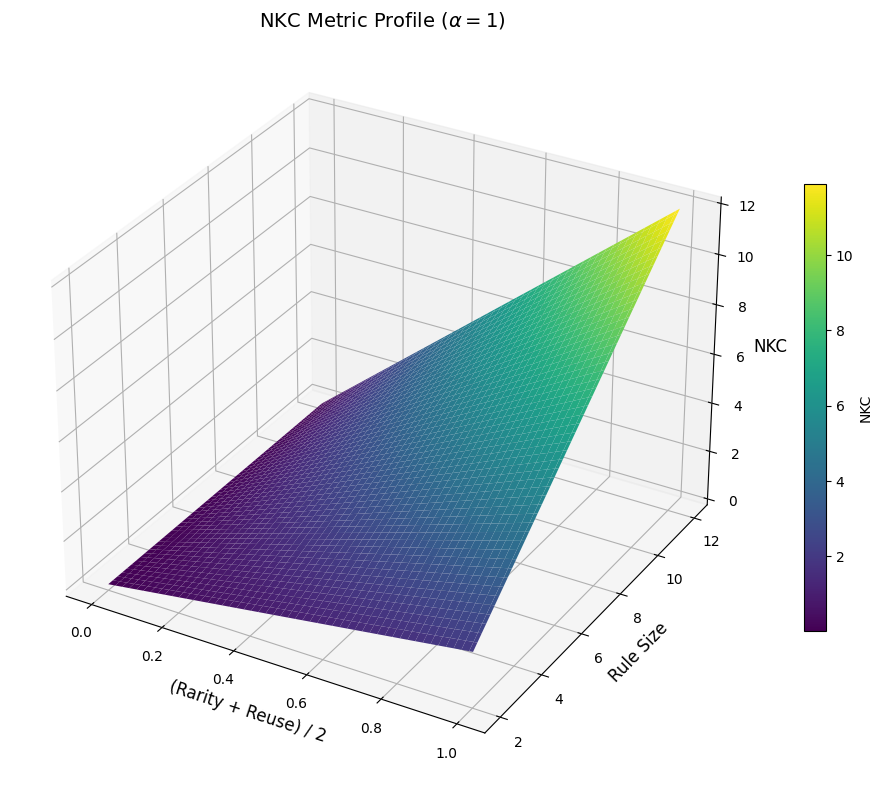

In [13]:
profile_nkc()

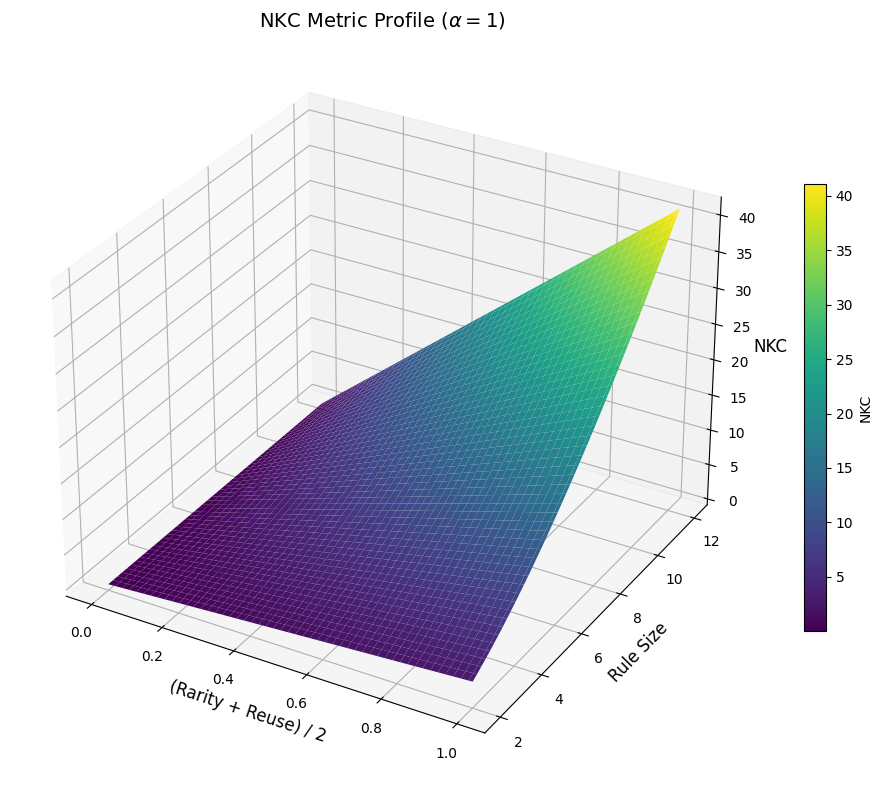

In [14]:
profile_nkc(1.5)

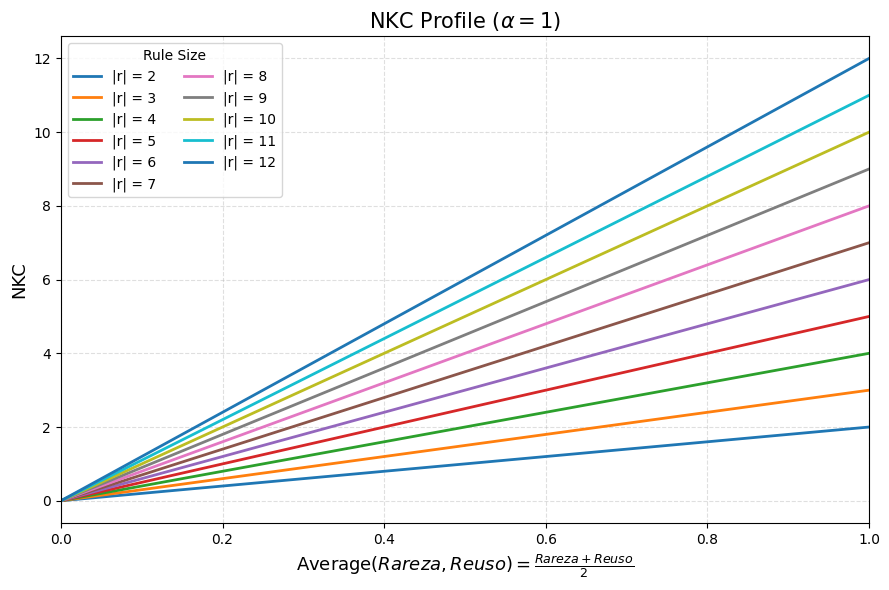

In [15]:
import numpy as np
import matplotlib.pyplot as plt

#############################################################
# NKC PROFILE (2D)
#############################################################

def profile_nkc(alpha=1):

    # Promedio entre rareza y reúso
    x = np.linspace(0, 1, 200)

    plt.figure(figsize=(9,6))

    for rule_size in range(2, 13):

        nkc = (rule_size ** alpha) * x

        plt.plot(
            x,
            nkc,
            linewidth=2,
            label=f"|r| = {rule_size}"
        )

    plt.title(
        r"NKC Profile ($\alpha = 1$)",
        fontsize=15
    )

    plt.xlabel(
        r"Average$(Rareza, Reuso)=\frac{Rareza+Reuso}{2}$",
        fontsize=13
    )

    plt.ylabel(
        "NKC",
        fontsize=13
    )

    plt.xlim(0,1)

    plt.grid(True, linestyle="--", alpha=0.4)

    plt.legend(
        title="Rule Size",
        ncol=2,
        fontsize=10
    )

    plt.tight_layout()

    plt.show()


#############################################################

if __name__ == "__main__":

    profile_nkc(alpha=1)